In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

def load_iteration_stats(sim_name, results_root="./results",
                         convert_to_years=True, average=True,
                         num_hum=None, num_mos=None):
    
    folder = os.path.join(results_root, sim_name)
    pattern = os.path.join(folder, "Iteration_proof_*.txt")
    files = sorted(glob.glob(pattern))

    if not files:
        raise FileNotFoundError(f"No encontré archivos con patrón: {pattern}")

    dfs = [pd.read_csv(f, sep=";") for f in files]
    df_all = pd.concat(dfs, ignore_index=True)

    # Tiempo a años
    if convert_to_years:
        df_all["time_years"] = df_all["time"] / 365.0
        xcol = "time_years"
    else:
        xcol = "time"

    # Conversiones a % (solo si existen columnas)
    if num_hum is not None:
        for c in ["HS", "HM", "HPC"]:
            if c in df_all.columns:
                df_all[c] = 100.0 * df_all[c] / float(num_hum)

    if num_mos is not None:
        for c in ["MS", "MC", "MPC"]:
            if c in df_all.columns:
                df_all[c] = 100.0 * df_all[c] / float(num_mos)

    # Si PI_Humans y PI_Mosquitoes están como fracción, pásalos a %
    for c in ["PI_Humans", "PI_Mosquitoes", "ratio_reco"]:
        if c in df_all.columns:
            df_all[c] = 100.0 * df_all[c]

    # Promedio y std por tiempo
    if average:
        numeric_cols = df_all.select_dtypes(include="number").columns
        # groupby por tiempo, agregando media y std para columnas numéricas
        df_stats = df_all.groupby(xcol)[numeric_cols].agg(["mean", "std"])
        df_stats.columns = ["_".join(col) for col in df_stats.columns]
        df_stats = df_stats.reset_index()
        return df_stats, xcol

    return df_all, xcol


def plot_panel_3_biting_rates(metric,
                             bite_rates,              # ej: ["1.2", "2.0", "10.0"]
                             igd_values=("10", "50", "90"),
                             num_humans=50,
                             mos_x_human=5,
                             results_root="./results/Main_Simulations",
                             outdir="./Figures/", name_fig = "",
                             convert_to_years=True,
                             average=True,
                             shade_std=True,
                             y_label=None,
                             y_lim=None,
                             colors_by_igd=None,
                             figsize=(15, 4.8), share_y = False):


    if len(bite_rates) != 3:
        raise ValueError("bite_rates debe tener exactamente 3 valores (bajo, medio, alto).")

    num_mosquitoes = num_humans * mos_x_human

    if colors_by_igd is None:
        # colores por defecto para IGD 10/50/90
        colors_by_igd = {str(igd_values[0]): "#B2182B",
                         str(igd_values[1]): "#E66101",
                         str(igd_values[2]): "#6A3D9A"}

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=share_y)
    fig.subplots_adjust(wspace=0.25)

    for ax, br in zip(axes, bite_rates):
        for igd in igd_values:
            sim_name = f"IGD_{igd}_BR_{br}_NH_{num_humans}_MxH_{mos_x_human}"

            try:
                df, xcol = load_iteration_stats(sim_name, results_root=results_root,
                                                convert_to_years=convert_to_years,average=average,
                                                num_hum=num_humans,num_mos=num_mosquitoes)
            except FileNotFoundError as e:
                print(f"[WARN] {e}")
                continue

            # Elegir columna Y según si hay promedio o no
            if average:
                y_mean = f"{metric}_mean"
                y_std  = f"{metric}_std"
                if y_mean not in df.columns:
                    print(f"[WARN] En {sim_name} no existe la columna {y_mean}. Columnas disponibles: {list(df.columns)[:10]} ...")
                    continue

                ax.plot(df[xcol], df[y_mean], label=f"{igd} %", color=colors_by_igd.get(str(igd), None))

                if shade_std and y_std in df.columns:
                    ax.fill_between(df[xcol],
                                    df[y_mean] - df[y_std],
                                    df[y_mean] + df[y_std],
                                    alpha=0.25,
                                    color=colors_by_igd.get(str(igd), None))
            else:
                if metric not in df.columns:
                    print(f"[WARN] En {sim_name} no existe la columna {metric}.")
                    continue
                ax.plot(df[xcol], df[metric], label=f"{igd} %", color=colors_by_igd.get(str(igd), None))
        
        ax.set_xlabel("Time (years)" if convert_to_years else "Time")
        ax.grid(axis="y", alpha=0.4)
        ax.set_ylabel(y_label if y_label is not None else metric)
        
        if(metric in ["PI_Humans","PI_Mosquitoes"]):
            ax.set_yticks([0,10,30,50,75,90])
        
        if (br == "0.3"):
            ax.set_title(f"Low Transmission")
        elif (br == "0.8"):
            ax.set_title(f"Moderate Transmission")
        elif (br == "3.0"):
            ax.set_title(f"High Transmission")

    # Etiquetas globales
    

    if y_lim is not None:
        axes[0].set_ylim(y_lim[0], y_lim[1])

    # Leyenda (solo una para que no estorbe)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=len(igd_values),
                   frameon=True, title = f"$\pi_0$", bbox_to_anchor=(0.5, 1.25))

    # Guardar
    safe_metric = metric.replace("/", "_")
    outpath = os.path.join(outdir, f"{name_fig}.png")
    plt.savefig(outpath, dpi=600, bbox_inches="tight")
    plt.show()

    return outpath


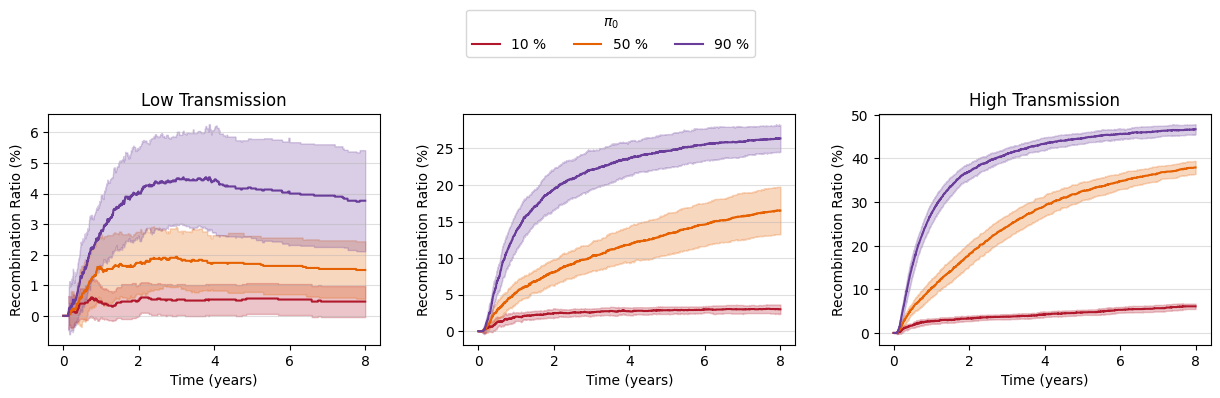

In [2]:
out = plot_panel_3_biting_rates(metric="ratio_reco", 
                                bite_rates=["0.3", "1.0", "3.0"],
                                igd_values=("10", "50", "90"),
                                num_humans=50,
                                mos_x_human=5,
                                y_label="Recombination Ratio (%)",
                                y_lim=None,
                                shade_std=True,figsize=(15, 3),
                                name_fig = 'Figure_S6A')

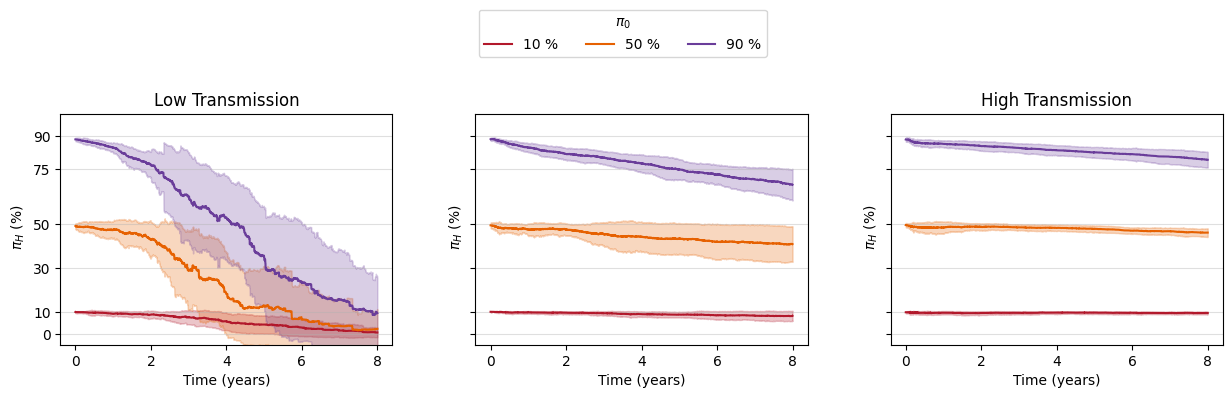

In [3]:
out = plot_panel_3_biting_rates( metric="PI_Humans", 
                                bite_rates=["0.3", "1.0", "3.0"],
                                igd_values=("10", "50", "90"),
                                num_humans=50,
                                mos_x_human=5,
                                y_label=" $\pi_H$ (%)",
                                y_lim=(-5,100),
                                shade_std=True,figsize=(15, 3), share_y = True,
                                name_fig = 'Figure_S6B')

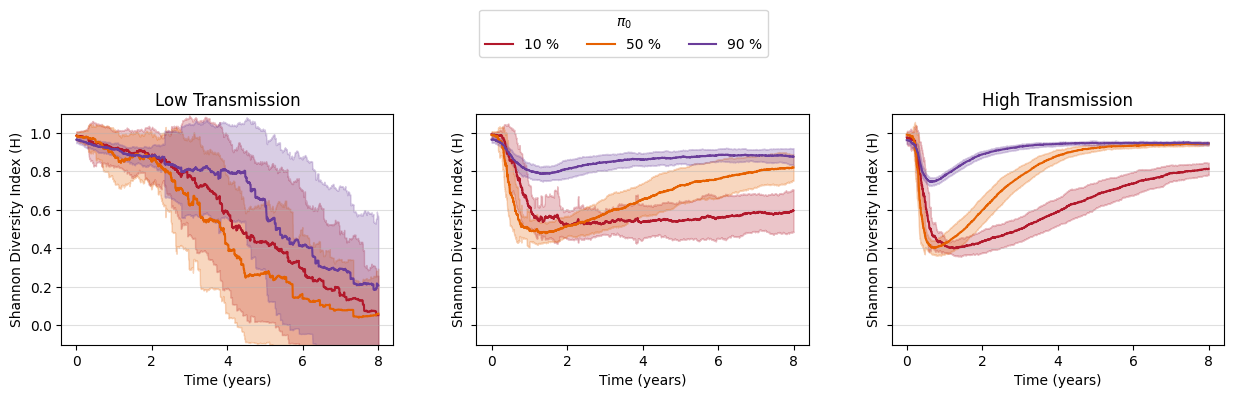

In [4]:
out = plot_panel_3_biting_rates( metric="SH_Humans", 
                                bite_rates=["0.3", "1.0", "3.0"],
                                igd_values=("10", "50", "90"),
                                num_humans=50,
                                mos_x_human=5,
                                y_label="Shannon Diversity Index (H)",
                                y_lim=(-.1,1.1),
                                shade_std=True,figsize=(15, 3), share_y = True,
                                name_fig = 'Figure_S6C')